<a href="https://colab.research.google.com/github/Jmiwa/gci-competition2/blob/main/baseline_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [ベースライン basic版] Supermarket Marketing Campaign

このノートブックでは、食品スーパーの顧客データから「キャンペーンに反応するかどうか（`target`）」を予測します。

basic版の目標は、次の流れを一度最後まで体験することです。

- データを読み込む
- データの中身を少し見る
- モデルに入れられる形へ整える
- モデルを学習して、手元でスコアを確認する
- 提出用CSVを作る

上から順番に実行すると、最後に `submission_basic.csv` が作成されます。

## 目次

1. セットアップ
2. データ読み込み
3. データの確認・EDA
4. 前処理
5. ベースラインモデル
6. 少しだけ特徴量エンジニアリング
7. 提出ファイル作成
8. つまずいたときの確認ポイント

## 1. セットアップ

まず、必要なライブラリを読み込みます。

ライブラリは、Pythonでデータ分析や機械学習を行うための便利な道具です。Colabには、ここで使う基本的なライブラリが最初から入っています。

In [59]:
# ライブラリのインポート
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

### データの置き方

このノートブックでは、`train.csv` と `test.csv` を使います。

一番かんたんな方法は、Colab画面の左側にあるファイル欄へ `train.csv` と `test.csv` をアップロードする方法です。

Google Driveを使う場合は、たとえば次のような配置を想定しています。

```text
マイドライブ/
└── supermarket/
    ├── baseline_basic.ipynb
    ├── train.csv
    ├── test.csv
    └── sample_submission.csv
```

- Google Colaboratoryを使う方で、pathの設定や「ドライブのマウント」の手順がわからない方は、以下をご参照ください。  
「Google Colabの使い方」  
https://drive.google.com/drive/folders/1iQfST6GKpCalOtOBq-14XLuSURUXUNkQ

In [60]:
# Google Driveのマウント（Colab上で自分のデータにアクセスするための設定です）
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
PATH = '/content/drive/MyDrive/Colab Notebooks/GCI2026_Summer/competition_2'

## 2. データ読み込み

`pd.read_csv()` を使って、CSVファイルを読み込みます。

- `train.csv`: 学習用データ。正解である `target` 列があります。
- `test.csv`: 予測対象データ。`target` 列はありません。

In [62]:
train = pd.read_csv(Path(PATH) / "data/train.csv")
test = pd.read_csv(Path(PATH) / "data/test.csv")

まず、データの行数と列数を確認します。

`shape` は `(行数, 列数)` の形で表示されます。

In [63]:
print("Train:", train.shape)
print("Test :", test.shape)

Train: (1568, 22)
Test : (672, 21)


訓練データとテストデータで列数が1つ違うのは、訓練データにだけ正解ラベル `target` が入っているためです。

In [64]:
train.head()

,customer_id,birth_year,education_level,marital_status,annual_income,num_children,num_teenagers,registration_date,days_since_last_purchase,spend_wines,...,spend_fish,spend_sweets,spend_gold,deals_purchases,web_purchases,catalog_purchases,store_purchases,monthly_web_visits,has_complaint,target
0,0,1993,Bachelor,Single,70515.0,0,0,2013-10-21,12,420,...,182,64,140,1,6,6,4,2,0,1
1,1,1983,Doctorate,Married,50150.0,0,0,2013-06-20,32,135,...,65,61,11,2,5,2,7,5,0,0
2,2,1992,Master,Single,92859.0,0,0,2012-10-19,46,962,...,52,61,20,1,5,4,12,2,0,0
3,3,1962,Doctorate,Partner,56067.0,0,1,2013-07-20,51,517,...,16,6,120,2,7,4,7,5,0,0
4,4,1967,Doctorate,Partner,56575.0,0,2,2013-05-05,42,421,...,0,16,10,3,7,3,7,5,0,0


In [65]:
test.head()

,customer_id,birth_year,education_level,marital_status,annual_income,num_children,num_teenagers,registration_date,days_since_last_purchase,spend_wines,...,spend_meat,spend_fish,spend_sweets,spend_gold,deals_purchases,web_purchases,catalog_purchases,store_purchases,monthly_web_visits,has_complaint
0,1568,1979,Associate,Partner,7500.0,1,0,2013-07-05,7,2,...,11,3,8,21,4,3,2,2,7,0
1,1569,1986,Bachelor,Married,83512.0,0,0,2014-06-17,31,1060,...,835,80,20,101,1,4,7,10,1,0
2,1570,1976,Bachelor,Divorced,40780.0,0,1,2012-08-09,30,229,...,71,13,3,34,4,7,1,5,9,0
3,1571,1965,Bachelor,Single,59686.0,0,1,2014-01-25,78,89,...,89,34,42,5,1,4,1,6,4,0
4,1572,1968,Bachelor,Single,75922.0,0,0,2013-09-12,60,265,...,553,224,23,92,1,4,4,9,1,0


`.info()` を使うと、列名・データ型・欠損値の有無をまとめて確認できます。

- `int64` / `float64`: 数値データ
- `object`: 文字データ、カテゴリデータ

In [66]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1568 non-null   int64  
 1   birth_year                1568 non-null   int64  
 2   education_level           1568 non-null   object 
 3   marital_status            1568 non-null   object 
 4   annual_income             1553 non-null   float64
 5   num_children              1568 non-null   int64  
 6   num_teenagers             1568 non-null   int64  
 7   registration_date         1568 non-null   object 
 8   days_since_last_purchase  1568 non-null   int64  
 9   spend_wines               1568 non-null   int64  
 10  spend_fruits              1568 non-null   int64  
 11  spend_meat                1568 non-null   int64  
 12  spend_fish                1568 non-null   int64  
 13  spend_sweets              1568 non-null   int64  
 14  spend_go

## 3. データの確認・EDA

EDAは、モデルを作る前にデータを観察する作業です。  
この段階で、データに含まれる傾向やパターン、欠損値、分布の偏りなどを明らかにします。

ここでは、次の3つを確認します。

- 欠損値はあるか
- `target` はどれくらい偏っているか
- カテゴリごとに `target` の平均が違いそうか

### 欠損値の確認

欠損値とは、データが空欄になっている部分です。

多くの機械学習モデルは欠損値があるとそのままでは学習できないため、まず確認します。

In [67]:
missing = pd.DataFrame({
    "train": train.isnull().sum(),
    "test": test.isnull().sum(),
}).fillna(0).astype(int)

missing

,train,test
annual_income,15,9
birth_year,0,0
catalog_purchases,0,0
customer_id,0,0
days_since_last_purchase,0,0
deals_purchases,0,0
education_level,0,0
has_complaint,0,0
marital_status,0,0
monthly_web_visits,0,0


`annual_income` に欠損値があることが分かります。これは後で中央値で埋めます。

### 目的変数 target の分布

`target` は、キャンペーンに反応したかどうかを表します。

- `0`: 反応しなかった
- `1`: 反応した

In [68]:
target_counts = train["target"].value_counts().sort_index()
target_counts

,count
target,
0,1334
1,234


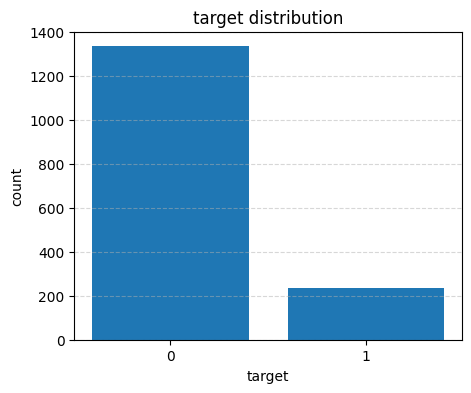

target=1 の割合: 0.149


In [69]:
plt.figure(figsize=(5, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("target distribution")
plt.xlabel("target")
plt.ylabel("count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

target_rate = train["target"].mean()
print(f"target=1 の割合: {target_rate:.3f}")

`target=1` の人は少なめです。

このように0と1の数に偏りがある場合、正解率（Accuracy）だけを見るとモデルの良し悪しが分かりにくいことがあります。このような不均衡データでは、単純なAccuracyではなく、**AUC（ROC-AUC）** を評価指標に使うことが一般的です。本コンペでもAUCが評価指標です。

### カテゴリデータの確認
カテゴリデータとは、いくつかのカテゴリー（グループ）に分けられるデータのことです。たとえば、性別（男性・女性）や血液型（A型・B型・O型・AB型）などがカテゴリデータの例です。

今回のデータの中から、`education_level` と `marital_status` を見てみましょう。

In [70]:
categorical_cols = ["education_level", "marital_status"]
train[categorical_cols].head()

,education_level,marital_status
0,Bachelor,Single
1,Doctorate,Married
2,Master,Single
3,Doctorate,Partner
4,Doctorate,Partner


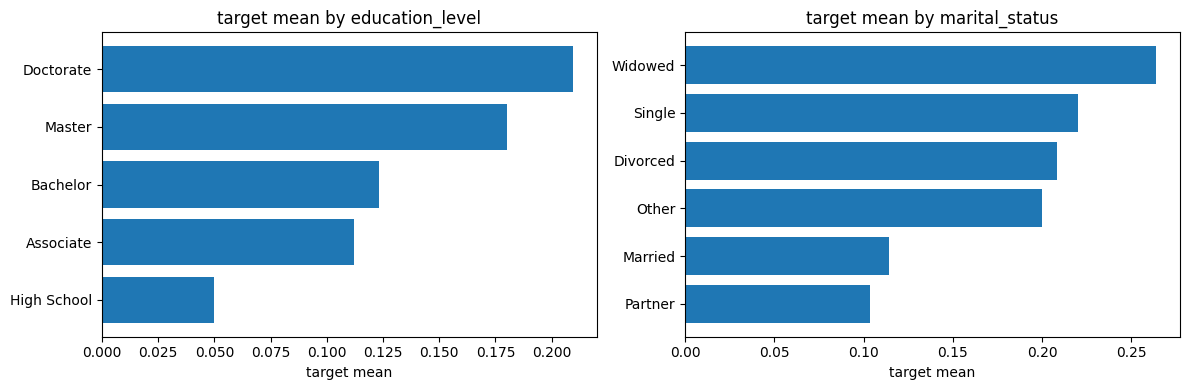

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(categorical_cols):
    target_mean = train.groupby(col)["target"].mean().sort_values()
    axes[i].barh(target_mean.index, target_mean.values)
    axes[i].set_title(f"target mean by {col}")
    axes[i].set_xlabel("target mean")

plt.tight_layout()
plt.show()

カテゴリごとに `target` の平均が違うことが分かります。

このような列を加工しモデルに渡すことは、予測するときのヒントになる可能性があります。

数値データもざっくり確認しておきます。

すべてを細かく読む必要はありません。まずは、どんな列があるか、値の範囲がどれくらいかを眺めるだけで大丈夫です。

In [72]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,1568.0,783.500000,452.786926,0.0,391.75,783.5,1175.25,1567.0
birth_year,1568.0,1968.823342,12.023484,1893.0,1959.00,1970.0,1977.00,1996.0
annual_income,1553.0,52402.623954,26796.156599,1730.0,35196.00,51412.0,68657.00,666666.0
num_children,1568.0,0.435587,0.528386,0.0,0.00,0.0,1.00,2.0
num_teenagers,1568.0,0.504464,0.541788,0.0,0.00,0.0,1.00,2.0
days_since_last_purchase,1568.0,49.071429,28.840759,0.0,24.75,49.0,74.00,99.0
spend_wines,1568.0,304.494898,337.010658,0.0,23.00,172.0,508.00,1493.0
spend_fruits,1568.0,26.155612,39.741202,0.0,1.00,8.0,33.00,199.0
spend_meat,1568.0,167.141582,223.495895,0.0,16.00,67.5,230.00,1725.0
spend_fish,1568.0,38.401786,55.975442,0.0,3.00,12.0,50.00,259.0


例えば、  `annual_income`の標準偏差は大きく、値のばらつきが大きいことが分かります。  
また、`birth_year` から100歳以上の差がある、幅広い年齢層の人がいることが分かります。

## 4. 前処理

前処理とは、モデルが学習できる形にデータを整える作業です。

今回は次の3つを行います。

- 欠損値を埋める
- 文字のカテゴリを数字に変換する
- そのままでは使いにくい列を外す

まず、元データを直接書き換えないようにコピーします。

In [73]:
train_pp = train.copy()
test_pp = test.copy()

### 欠損値を埋める
多くの機械学習モデルは、欠損値があるとそのままでは学習できません。

そこで、`annual_income` の欠損値を、訓練データの中央値で埋めます。

中央値は極端に大きい値や小さい値の影響を受けにくいので、収入のような列で使いやすいです。

In [74]:
income_median = train_pp["annual_income"].median()

train_pp["annual_income"] = train_pp["annual_income"].fillna(income_median)
test_pp["annual_income"] = test_pp["annual_income"].fillna(income_median)

print("補完に使った annual_income の中央値:", income_median)

補完に使った annual_income の中央値: 51412.0


### カテゴリデータを数字に変換する

多くの機械学習モデルは、文字データをそのまま扱えません。

そこで、`Bachelor` や `Single` のような文字を、0, 1, 2, ... のような数字に変換します。ここでは **Label Encoding** を使います。  

実際に自分でコンペに取り組む場合には他のエンコーディング手法も試してみると良いでしょう。

In [75]:
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(pd.concat([train_pp[col], test_pp[col]]).astype(str))
    train_pp[col] = le.transform(train_pp[col].astype(str))
    test_pp[col] = le.transform(test_pp[col].astype(str))
    label_encoders[col] = le

train_pp[categorical_cols].head()

,education_level,marital_status
0,1,4
1,2,1
2,4,4
3,2,3
4,2,3


### 使わない列を外す

`customer_id` は顧客を区別するための番号なので、予測の材料から外します。

`registration_date` は日付ですが、basic版では扱いを簡単にするため、いったん外します。

In [76]:
drop_cols = ["customer_id", "registration_date"]

train_pp = train_pp.drop(columns=drop_cols)
test_pp = test_pp.drop(columns=drop_cols)

train_pp.head()

,birth_year,education_level,marital_status,annual_income,num_children,num_teenagers,days_since_last_purchase,spend_wines,spend_fruits,spend_meat,spend_fish,spend_sweets,spend_gold,deals_purchases,web_purchases,catalog_purchases,store_purchases,monthly_web_visits,has_complaint,target
0,1993,1,4,70515.0,0,0,12,420,0,452,182,64,140,1,6,6,4,2,0,1
1,1983,2,1,50150.0,0,0,32,135,46,92,65,61,11,2,5,2,7,5,0,0
2,1992,4,4,92859.0,0,0,46,962,61,921,52,61,20,1,5,4,12,2,0,0
3,1962,2,3,56067.0,0,1,51,517,12,54,16,6,120,2,7,4,7,5,0,0
4,1967,2,3,56575.0,0,2,42,421,5,90,0,16,10,3,7,3,7,5,0,0


最後に、欠損値が残っていないか確認します。

In [77]:
print("Trainの欠損値数:", train_pp.isnull().sum().sum())
print("Test の欠損値数:", test_pp.isnull().sum().sum())

Trainの欠損値数: 0
Test の欠損値数: 0


## 5. ベースラインモデル

ベースラインモデルとは、最初に作るシンプルな基準モデルです。

今回は、表形式データで扱いやすい **RandomForestClassifier** を使います。

まず、特徴量 `X` と目的変数 `y` に分けます。

- `X`: 予測に使う列
- `y`: 予測したい正解ラベル

In [78]:
X = train_pp.drop(columns=["target"])
y = train_pp["target"]

手元でモデルの性能を見るため、訓練データをさらに `train` と `valid` に分けます。

モデルは `train` で学習し、まだ見ていない `valid` でスコアを確認します。

In [79]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=5,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

valid_pred = model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, valid_pred)

print(f"Validation AUC: {auc:.4f}")

Validation AUC: 0.8207


`predict_proba(X_valid)[:, 1]` は、「`target=1` である確率」を取り出しています。

AUCは、0.5に近いとランダムに近く、1.0に近いほど良い予測です。

## 6. 特徴量エンジニアリング

特徴量エンジニアリングとは、元の列を組み合わせて新しい列を作ることです。

ここでは、分かりやすい1つだけ作ります。

- `children_total`: `num_children` と `num_teenagers` を足した列。

子供が多いほど、キャンペーンに反応する可能性があるかもしれません。

In [80]:
train_fe = train_pp.copy()
test_fe = test_pp.copy()

for df in [train_fe, test_fe]:
    df["children_total"] = df["num_children"] + df["num_teenagers"]

train_fe[["num_children", "num_teenagers", "children_total"]].head()

,num_children,num_teenagers,children_total
0,0,0,0
1,0,0,0
2,0,0,0
3,0,1,1
4,0,2,2


新しい特徴量を加えた状態で、もう一度同じ流れでモデルを学習します。

In [81]:
X_fe = train_fe.drop(columns=["target"])
y_fe = train_fe["target"]

X_train_fe, X_valid_fe, y_train_fe, y_valid_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.3,
    random_state=42,
    stratify=y_fe,
)

model_fe = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1,
)

model_fe.fit(X_train_fe, y_train_fe)

valid_pred_fe = model_fe.predict_proba(X_valid_fe)[:, 1]
auc_fe = roc_auc_score(y_valid_fe, valid_pred_fe)

print(f"Validation AUC after feature engineering: {auc_fe:.4f}")

Validation AUC after feature engineering: 0.7908


スコアを比べてみましょう。

特徴量を増やすと必ず良くなるわけではありません。良くなることもあれば、あまり変わらないこともあります。

In [82]:
score_table = pd.DataFrame({
    "model": ["basic", "feature_engineering"],
    "valid_auc": [auc, auc_fe],
})

score_table

,model,valid_auc
0,basic,0.820716
1,feature_engineering,0.790827


今回の提出では、Feature Engineering ありのモデルを提出することにします。

In [83]:
final_model = model_fe
final_test = test_fe
selected_model_name = "feature_engineering"

print("提出に使うモデル:", selected_model_name)

提出に使うモデル: feature_engineering


## 7. 提出ファイル作成

最後に、`test.csv` の各顧客について `target=1` である確率を予測し、提出用CSVを作ります。

In [84]:
sample_submission = pd.read_csv(PATH + '/data/sample_submission.csv')

In [85]:
test_pred = final_model.predict_proba(final_test)[:, 1]

sample_submission["target"] = test_pred

sample_submission.head()

,customer_id,target
0,1568,0.156793
1,1569,0.449291
2,1570,0.118274
3,1571,0.081989
4,1572,0.193641


In [86]:
output_path = PATH + '/submission_' + selected_model_name + '.csv'
sample_submission.to_csv(output_path, index=False)

print("提出ファイルを作成しました:", output_path)

提出ファイルを作成しました: /content/drive/MyDrive/Colab Notebooks/GCI2026_Summer/competition_2/submission_feature_engineering.csv


Colabで作成したCSVを手元のPCにダウンロードしたい場合は、次のセルを実行してください。

In [87]:
from google.colab import files

files.download(str(output_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. つまずいたときの確認ポイント

エラーが出たときは、まずエラー文の一番下を見てください。

- `FileNotFoundError`: `train.csv` と `test.csv` の場所が見つかっていません。colabのマウントを確認してください。
- `NameError`: 途中のセルが実行されていない可能性があります。上から順番に実行し直してください。
- `KeyError`: 列名が見つからないという意味です。別のデータを読み込んでいないか、セルを二重に実行して列を消していないか確認してください。
- AUCが毎回少し違う: `random_state` を変えると結果も変わります。このノートブックでは再現しやすいように `42` に固定しています。

次のステップとしては、baseline_advanced.ipynbで、さらに工夫を加えたモデルを作ってみましょう。